In [1]:
!pip install squidpy
!pip install cellcharter
!pip install lightning
!pip install scvi-colab

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of dask-expr to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.3/161.3 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Restart session
exit()

In [1]:
# Install SCVI
import scvi_colab

scvi_colab.install()
!pip install scvi-tools

INFO     scvi-colab: Installing scvi-tools.                                                                        
INFO     scvi-colab: Install successful. Testing import.                                                           


In [2]:
!pip uninstall scipy && pip install scipy

Found existing installation: scipy 1.14.1
Uninstalling scipy-1.14.1:
  Would remove:
    /usr/local/lib/python3.11/dist-packages/scipy-1.14.1.dist-info/*
    /usr/local/lib/python3.11/dist-packages/scipy.libs/libgfortran-040039e1-0352e75f.so.5.0.0
    /usr/local/lib/python3.11/dist-packages/scipy.libs/libgfortran-040039e1.so.5.0.0
    /usr/local/lib/python3.11/dist-packages/scipy.libs/libquadmath-96973f99-934c22de.so.0.0.0
    /usr/local/lib/python3.11/dist-packages/scipy.libs/libquadmath-96973f99.so.0.0.0
    /usr/local/lib/python3.11/dist-packages/scipy.libs/libscipy_openblas-c128ec02.so
    /usr/local/lib/python3.11/dist-packages/scipy/*
Proceed (Y/n)? Y
  Successfully uninstalled scipy-1.14.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 16.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source

In [3]:
!pip uninstall seaborn && pip install seaborn

Found existing installation: seaborn 0.13.2
Uninstalling seaborn-0.13.2:
  Would remove:
    /usr/local/lib/python3.11/dist-packages/seaborn-0.13.2.dist-info/*
    /usr/local/lib/python3.11/dist-packages/seaborn/*
Proceed (Y/n)? Y
  Successfully uninstalled seaborn-0.13.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 6.8 MB/s eta 0:00:00


In [4]:
# Restart session
exit()

In [1]:
import os
import gc
import scvi
import scipy
import torch
import random
import anndata

import numpy as np
import pandas as pd
import seaborn as sns
import squidpy as sq
import lightning as pl
import cellcharter as cc
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from lightning.pytorch import seed_everything
from scipy.sparse.csgraph import connected_components

/usr/local/lib/python3.11/dist-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
print("Scvi-tools version:", scvi.__version__)

Scvi-tools version: 1.3.1.post1


In [3]:
def set_seed(seed: int = 42) -> None:
    """ Function setting the seed, for the repeatability
    of the experiment.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    pl.seed_everything(seed)
    scvi.settings.seed = seed
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


In [4]:
from google.colab import drive
drive.mount('/content/drive')
TRAIN_ANNDATA_PATH = '/content/drive/MyDrive/data/train_adata.h5ad'

sns.set_theme()
plt.rcParams['figure.figsize'] = (12, 9)

train_anndata = anndata.read_h5ad(TRAIN_ANNDATA_PATH)
print(train_anndata)

Mounted at /content/drive
AnnData object with n_obs × n_vars = 253433 × 40
    obs: 'image', 'sample_id', 'ObjectNumber', 'Pos_X', 'Pos_Y', 'area', 'major_axis_length', 'minor_axis_length', 'eccentricity', 'width_px', 'height_px', 'acquisition_id', 'SlideId', 'Study', 'Box.Description', 'Position', 'SampleId', 'Indication', 'BatchId', 'SubBatchId', 'ROI', 'ROIonSlide', 'includeImage', 'flag_no_cells', 'flag_no_ROI', 'flag_total_area', 'flag_percent_covered', 'small_cell', 'celltypes', 'flag_tumor', 'PD1_pos', 'Ki67_pos', 'cleavedPARP_pos', 'GrzB_pos', 'tumor_patches', 'distToCells', 'CD20_patches', 'Batch', 'cell_labels', 'classifier'
    var: 'channel', 'use_channel', 'marker'
    layers: 'exprs'


# PCA

In [5]:
# Standardisation for PCA on cells' marker expression
expressions = train_anndata.layers['exprs']
total_counts = expressions.sum(axis=1, keepdims=True)
norm_exprs = (expressions / total_counts) * 1e6
norm_exprs = np.log1p(norm_exprs)
train_anndata.layers['normalised_exprs'] = norm_exprs

# PCA explaining 100% of variance
pca = PCA(svd_solver='full')
pca_exprs = pca.fit_transform(norm_exprs)
print(f"PCA: Number of components = {pca_exprs.shape[1]}, Explained variance = {pca.explained_variance_ratio_.sum():.2f}")

train_anndata.obsm['X_PCA'] = pca_exprs

PCA: Number of components = 40, Explained variance = 1.00


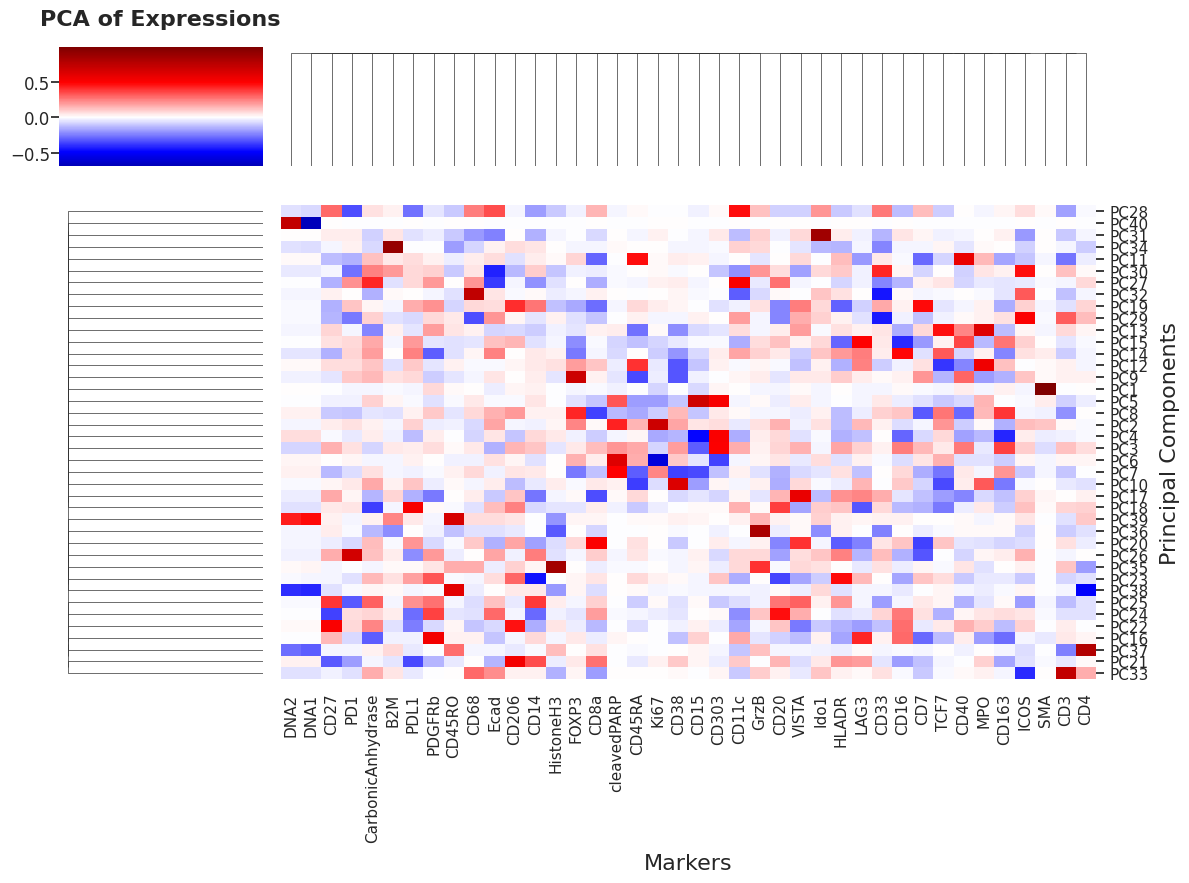

In [6]:
def plot_clustermap(data: pd.DataFrame,
                    x_labels: pd.DataFrame,
                    shape: int,
                    title: str) -> None:
    """ Helper function for plotting clustermap.
    """
    plot = sns.clustermap(
        data,
        cmap='seismic',
        center=0.0,
        xticklabels=x_labels,
        yticklabels=[f"PC{idx+1}" for idx in range(shape)],
        figsize=plt.rcParams['figure.figsize'],
    )

    # Improved layout for the plot
    cbar = plot.ax_heatmap.collections[0].colorbar
    cbar.ax.tick_params(labelsize=12,
                        pad=0.10,
                        labelleft=True,
                        labelright=False,
                        left=True,
                        right=False
    )

    plot.ax_heatmap.set_xlabel('Markers', fontsize=16, labelpad=8)
    plot.ax_heatmap.set_ylabel('Principal Components', fontsize=16, labelpad=8)
    plt.title(title, fontsize=16, pad=16, loc='center', weight='bold')
    plt.tight_layout()
    plt.show()
    plt.close()


plot_clustermap(pca.components_,
                train_anndata.var['marker'],
                pca_exprs.shape[1],
                'PCA of Expressions'
)

# Cellcharter again

In [7]:
def plot_heatmap(data: pd.DataFrame,
                 title: str,
                 fmt: str,
                 figsize: tuple = None,
                 xlabel: str = "Cell Types") -> None:
    """ Helper function for plotting heatmap.
    """
    if figsize:
        plt.figure(figsize=figsize)
        sns.heatmap(data, annot=True, fmt=fmt, cmap=sns.cubehelix_palette(as_cmap=True))
    else:
        plt.figure(figsize=plt.rcParams['figure.figsize'])
        sns.heatmap(data, annot=True, fmt=fmt, cmap="crest")

    plt.title(title, weight='bold', fontsize=20, pad=12)
    plt.xlabel(xlabel, fontsize=16, labelpad=8)
    plt.ylabel("Clusters", fontsize=16, labelpad=8)
    plt.tight_layout()
    plt.show()
    plt.close()

In [8]:
train_anndata.obsm['spatial'] = train_anndata.obs[['Pos_X', 'Pos_Y']].values

sq.gr.spatial_neighbors(
    train_anndata,
    library_key='sample_id',
    coord_type='generic',
    delaunay=True,
    spatial_key='spatial',
    percentile=99,
)

In [9]:
cc.gr.aggregate_neighbors(
    train_anndata,
    n_layers=4,
    use_rep='X_PCA',
    out_key='X_cellcharter',
    sample_key='sample_id'
)

  0%|          | 0/132 [00:00<?, ?it/s]

In [10]:
# Defining params for AutoK model to find best candidate for the number of clusters
n_clusters = range(2, 32)
accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'

model_params = {
        'random_state': 42,
        'trainer_params': {
            'accelerator': accelerator,
            'enable_progress_bar': False
        },
}

In [11]:
model = cc.tl.ClusterAutoK(n_clusters=n_clusters,
                           model_class=cc.tl.GaussianMixture,
                           model_params=model_params,
                           max_runs=16
)

# Change to float32 for compatibility of numpy and torch
train_anndata.obsm["X_cellcharter"] = train_anndata.obsm["X_cellcharter"].astype(np.float32)

# Taking every 10th example to faster computations
model.fit(train_anndata[::10], use_rep='X_cellcharter')

Iteration 1/16


  0%|          | 0/30 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytor

Iteration 2/16


  0%|          | 0/30 [00:00<?, ?it/s]

...

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytor

Iteration 14/16


  0%|          | 0/30 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytor

Convergence with a change in stability of 0.00964311859697563 reached after 14 iterations


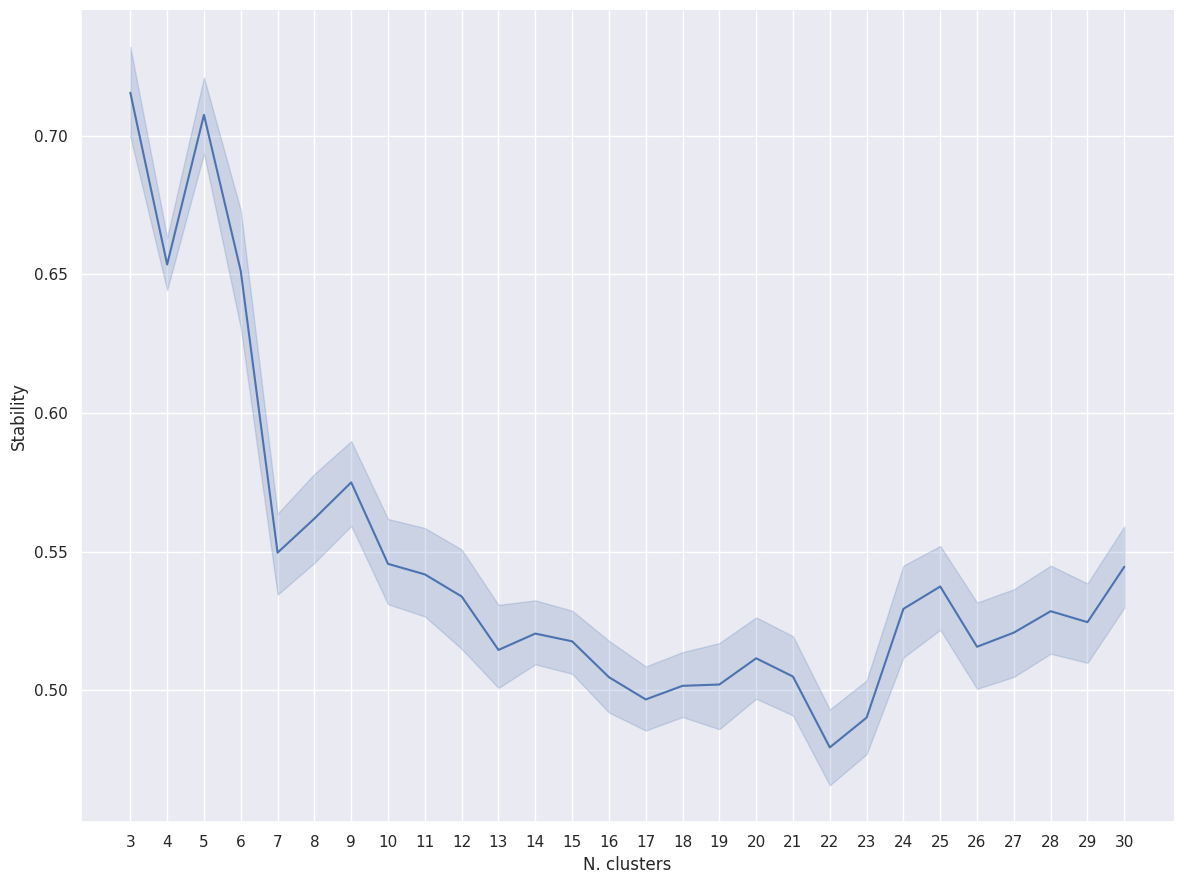

In [12]:
# Choose the best number of clusters with peaks of stability
cc.pl.autok_stability(model)
plt.tight_layout()
plt.show()
plt.close()

In [13]:
best_cluster = model.best_k
print(f"In our case for PCA, {best_cluster} is the best candidate!")
train_anndata.obs['cluster_cellcharter'] = model.predict(train_anndata, use_rep='X_cellcharter', k=best_cluster)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In our case for PCA, 3 is the best candidate!


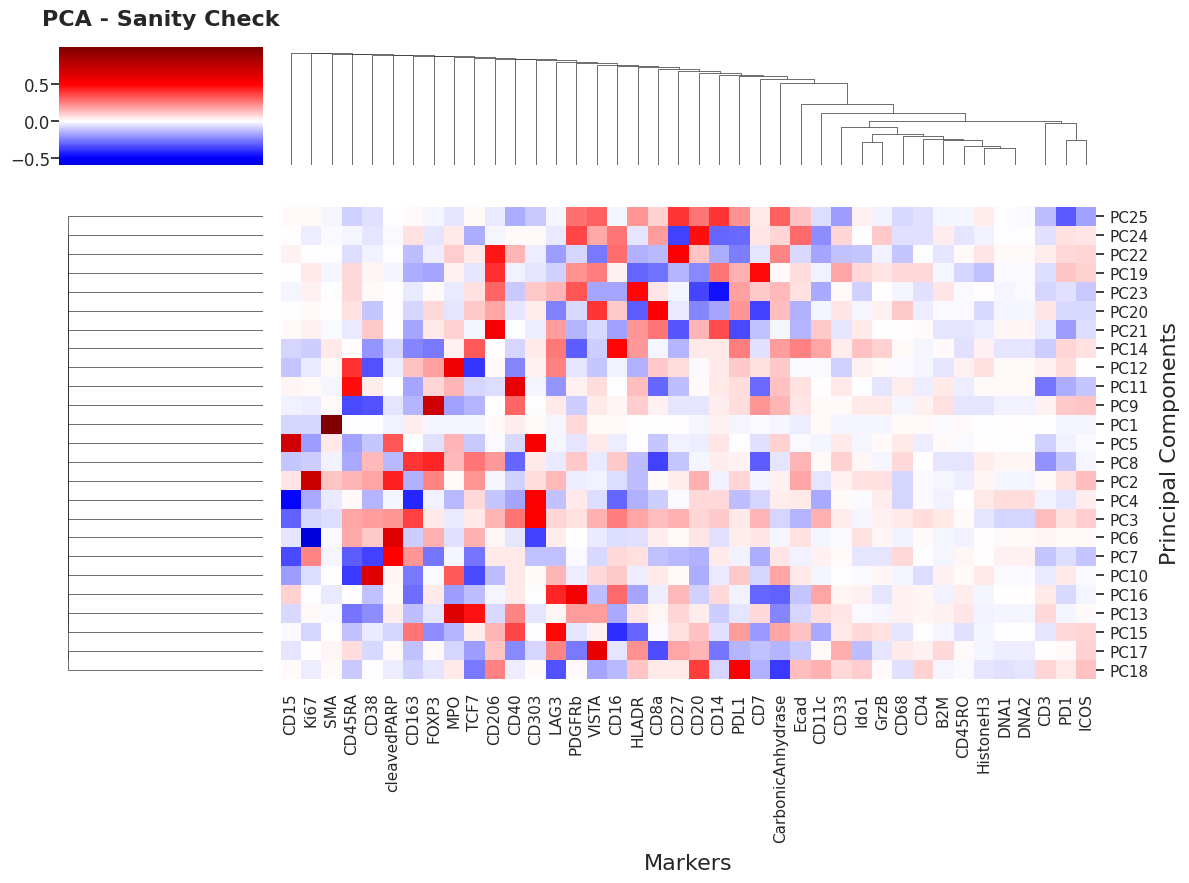

In [14]:
# Sanity check for PCA
cluster_pca_model = PCA(n_components=0.95, svd_solver='full')
cluster_pca_exprs = cluster_pca_model.fit_transform(train_anndata.layers['normalised_exprs'])

plot_clustermap(cluster_pca_model.components_,
                train_anndata.var['marker'],
                cluster_pca_exprs.shape[1],
                'PCA - Sanity Check'
)

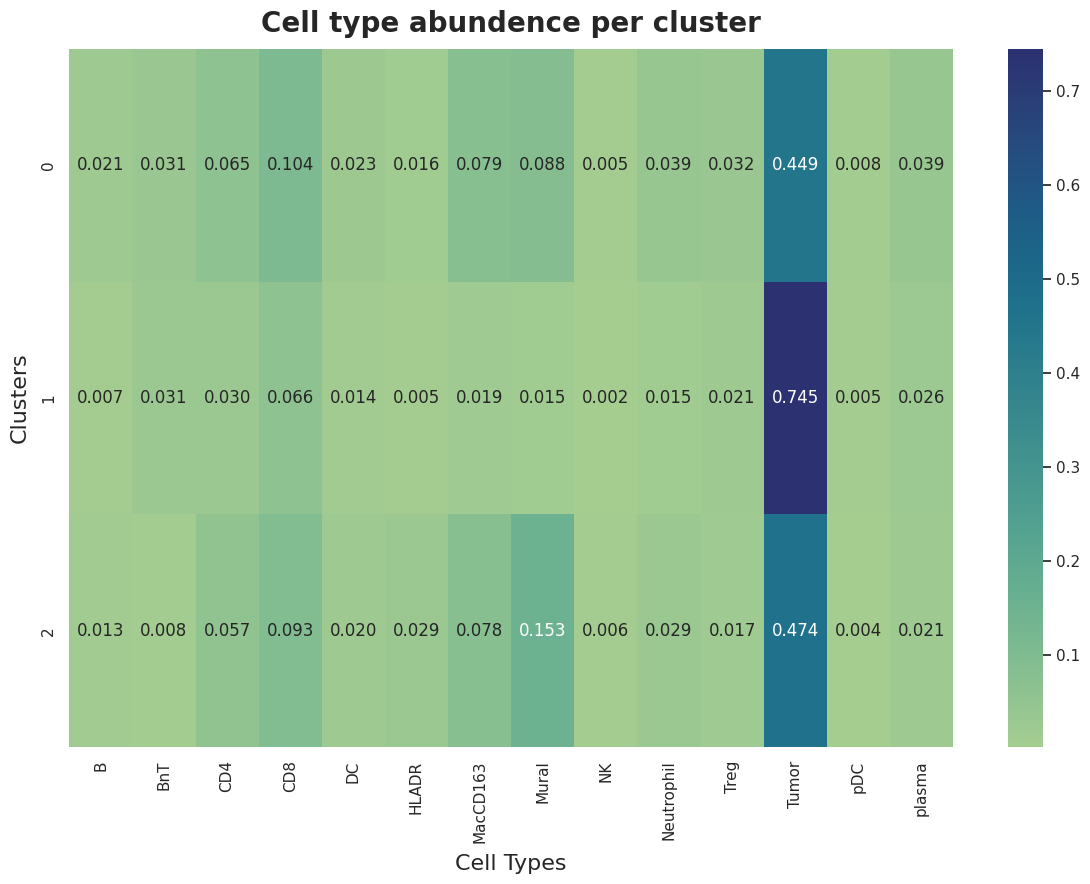

In [15]:
# Cell type abundance
cell_type_abundance = train_anndata.obs.groupby('cluster_cellcharter', observed=True)['celltypes']\
                      .value_counts(normalize=True).unstack()
plot_heatmap(cell_type_abundance, "Cell type abundence per cluster", ".3f")

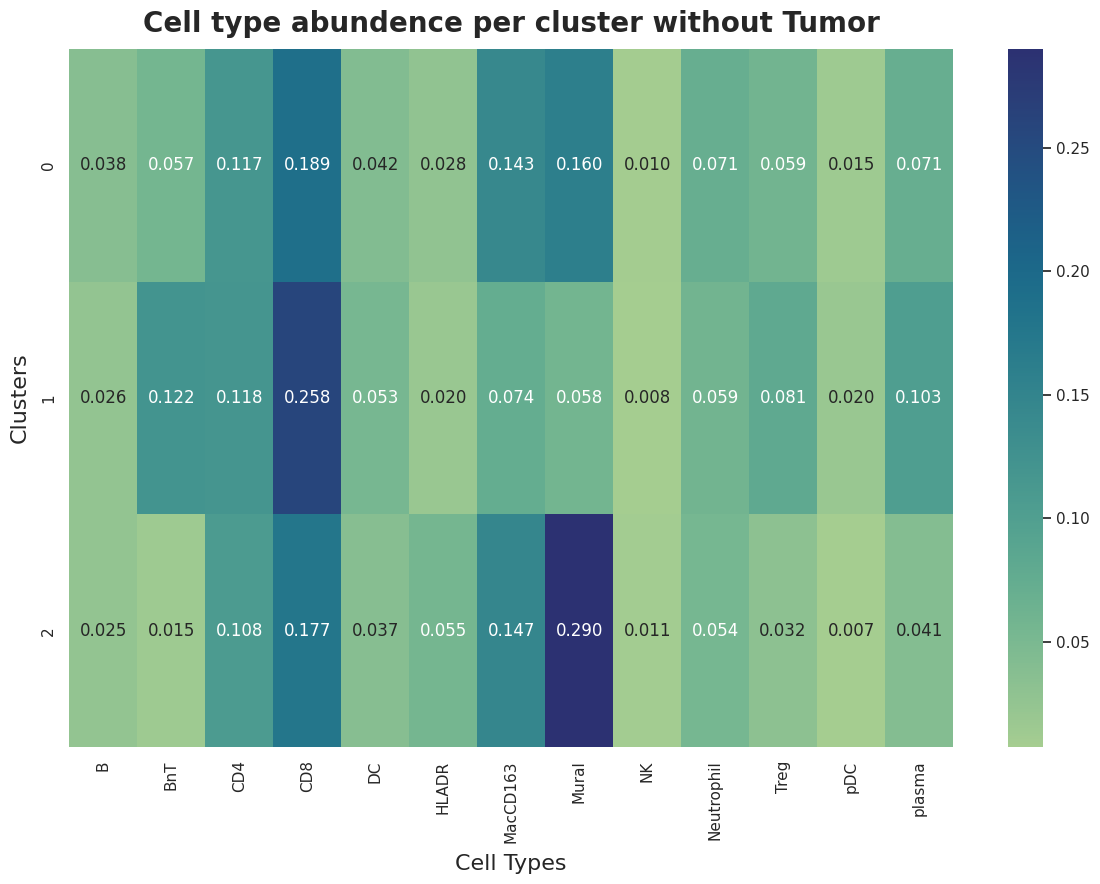

In [16]:
# Cell type abundance without Tumor
cell_type_abundance = train_anndata.obs.groupby('cluster_cellcharter', observed=True)['celltypes']\
                      .value_counts().unstack()
cell_type_abundance.drop(columns=['Tumor'], inplace=True)
cell_type_abundance = cell_type_abundance.div(cell_type_abundance.sum(axis=1), axis=0)
plot_heatmap(cell_type_abundance, "Cell type abundence per cluster without Tumor", ".3f")

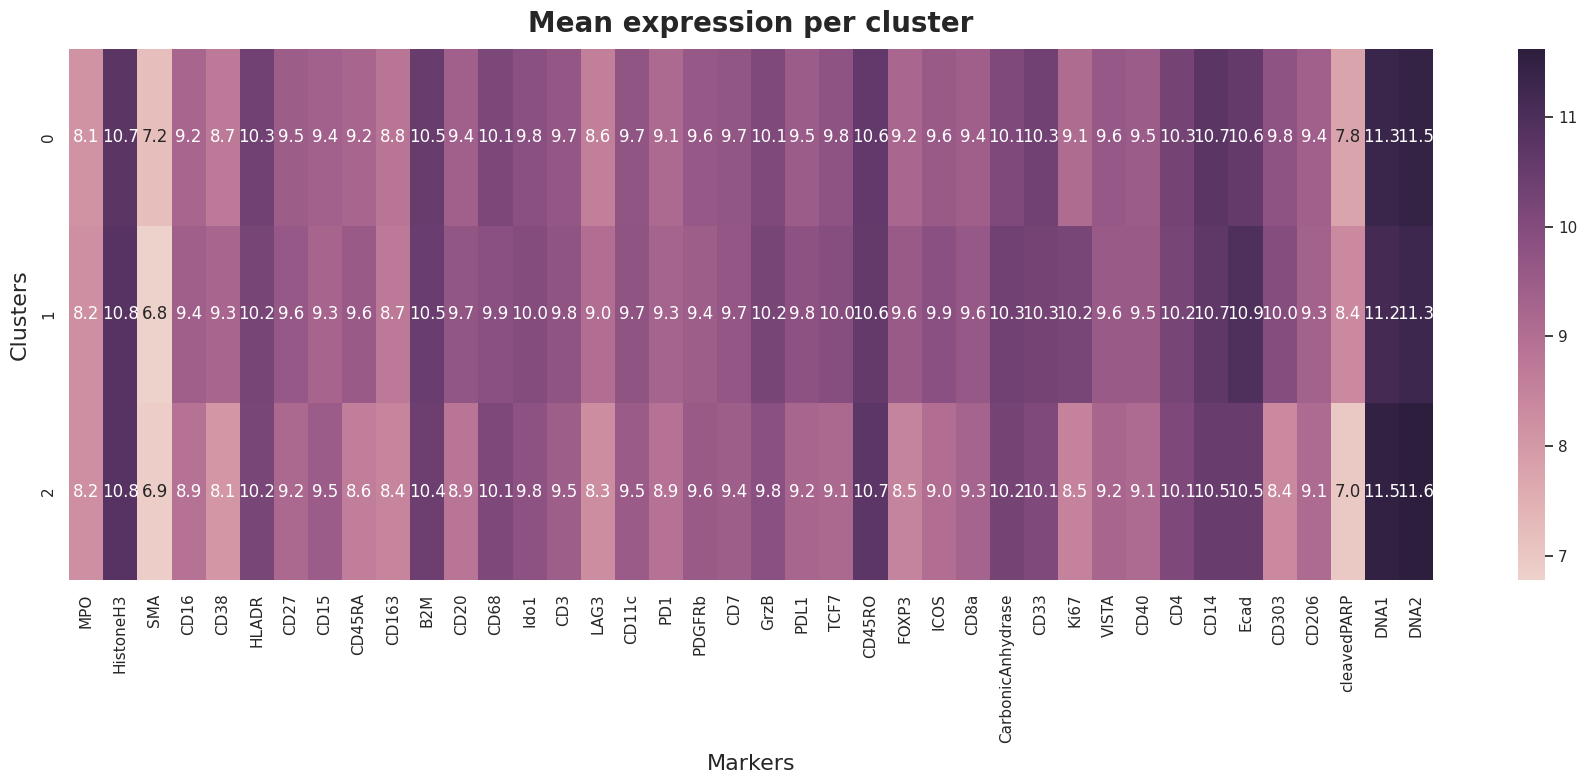

In [17]:
# Mean marker analysis
clusters_exprs = []

for cluster in range(best_cluster):
    mask = train_anndata.obs['cluster_cellcharter'] == cluster
    cluster_data = train_anndata.layers['normalised_exprs'][mask, :]
    clusters_exprs.append(cluster_data.mean(axis=0))

# Make DataFrame to plot
expressions_clusters_df = pd.DataFrame(
    np.stack(clusters_exprs),
    columns=train_anndata.var['marker'],
    index=[f'{i}' for i in range(best_cluster)]
)

plot_heatmap(expressions_clusters_df, "Mean expression per cluster", ".1f", (18, 8), "Markers")

TODO

# scVI

In [18]:
scvi.model.SCVI.setup_anndata(train_anndata,
                              layer="exprs",
                              batch_key="Batch"
)

model = scvi.model.SCVI(train_anndata,
                        n_latent=40,
                        gene_likelihood="nb"
)
model.train(max_epochs=100,
            accelerator=accelerator,
            early_stopping=True,
            enable_progress_bar=True
)

/usr/local/lib/python3.11/dist-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[exprs] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Training:   0%|          | 0/100 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


In [19]:
latent = model.get_latent_representation()
train_anndata.obsm["X_SCVI"] = latent

In [20]:
cc.gr.aggregate_neighbors(
train_anndata,
n_layers=4,
use_rep='X_SCVI',
out_key='X_agg_SCVI',
sample_key='sample_id'
)

  0%|          | 0/132 [00:00<?, ?it/s]

In [ ]:
model_scvi = cc.tl.ClusterAutoK(n_clusters=n_clusters,
                                model_class=cc.tl.GaussianMixture,
                                model_params=model_params,
                                max_runs=16
)

train_anndata.obsm["X_agg_SCVI"] = train_anndata.obsm["X_agg_SCVI"].astype(np.float32)

model_scvi.fit(train_anndata[::10], use_rep='X_agg_SCVI')

Iteration 1/16


  0%|          | 0/30 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytor

Iteration 2/16


  0%|          | 0/30 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytor

In [ ]:
cc.pl.autok_stability(model_scvi)
plt.tight_layout()
plt.show()
plt.close()

In [ ]:
best_cluster = model_scvi.best_k
print(f"In SCVI case, {best_cluster} is the best candidate!")
train_anndata.obs['cluster_scvi'] = model_scvi.predict(train_anndata, use_rep='X_agg_SCVI', k=best_cluster)

In [ ]:
# Cell type abundance SCVI
cell_type_abundance = train_anndata.obs.groupby('cluster_scvi', observed=True)['celltypes']\
                      .value_counts(normalize=True).unstack()
plot_heatmap(cell_type_abundance, "SCVI - Cell type abundence per cluster", ".3f")

In [ ]:
# Cell type abundance without Tumor SCVI
cell_type_abundance = train_anndata.obs.groupby('cluster_scvi', observed=True)['celltypes']\
                      .value_counts().unstack()
cell_type_abundance.drop(columns=['Tumor'], inplace=True)
cell_type_abundance = cell_type_abundance.div(cell_type_abundance.sum(axis=1), axis=0)
plot_heatmap(cell_type_abundance, "SCVI - Cell type abundence per cluster without Tumor", ".3f")

In [ ]:
# Mean marker analysis SCVI
clusters_exprs = []

for cluster in range(best_cluster):
    mask = train_anndata.obs['cluster_scvi'] == cluster
    cluster_data = train_anndata.layers['normalised_exprs'][mask, :]
    clusters_exprs.append(cluster_data.mean(axis=0))

expressions_clusters_df = pd.DataFrame(
    np.stack(clusters_exprs),
    columns=train_anndata.var['marker'],
    index=[f'{i}' for i in range(best_cluster)]
)

plot_heatmap(expressions_clusters_df, "SCVI - Mean expression per cluster", ".1f", (18, 8), "Markers")

TODO

In [ ]:
# Clear cache
gc.collect()

# Comparison

In [ ]:
def make_cross_matrix(obs, col1, col2, normalize=True):
    """ Function returns a DataFrame with a
    cross-sectional matrix and percentages.
    """
    ct = pd.crosstab(obs[col1], obs[col2])
    if normalize:
        ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
        return ct, ct_pct

    return ct, None


def plot_cross_heatmap(ct_raw, ct_pct, title: str) -> None:
    """ Function plots a heatmap of a cross-count matrix.
    """
    plt.figure(figsize=plt.rcParams['figure.figsize'])
    ax = sns.heatmap(
        ct_raw,
        annot=False,
        fmt='d',
        cmap='YlOrBr',
        cbar_kws={'label': 'Number of Cells', 'pad': 0.05}
    )

    for i in range(ct_raw.shape[0]):
        for j in range(ct_raw.shape[1]):
            raw = ct_raw.iloc[i, j]
            pct = ct_pct.iloc[i, j]
            color = 'white' if raw >= 37000 else 'black'
            ax.text(
                j + 0.5, i + 0.4,
                f"{raw}",
                ha='center', va='center',
                color=color,
                fontsize=12, weight='bold'
            )
            ax.text(
                j + 0.5, i + 0.6,
                f"({pct:.1f}%)",
                ha='center', va='center',
                color=color,
                fontsize=8
            )

    ax.set_title(title, fontsize=16, pad=12, weight='bold')
    ax.set_xlabel(ct_raw.columns.name or '', fontsize=12)
    ax.set_ylabel(ct_raw.index.name or '', fontsize=12)
    plt.tight_layout()
    plt.show()
    plt.close()

In [ ]:
for name_a, name_b in [('cluster_scvi','cluster_cellcharter')]:
    ct_left, ct_right = make_cross_matrix(train_anndata.obs, name_a, name_b)
    plot_cross_heatmap(ct_left, ct_right, f"Clusters SCvi vs PCA")

TODO

# BERT-Charter

In [ ]:
!pip install --upgrade networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 33.0 MB/s eta 0:00:00
  Attempting uninstall: networkx
    Found existing installation: networkx 3.4.2
    Uninstalling networkx-3.4.2:
      Successfully uninstalled networkx-3.4.2


In [ ]:
import networkx as nx
import torch.nn as nn
import scipy.sparse as sp
import torch.optim as optim
import torch.nn.functional as F

from sklearn.cluster import KMeans
from tqdm.notebook import trange, tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torch.nn import TransformerEncoder, TransformerEncoderLayer

In [ ]:
gc.collect()

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
N_LAYERS = 4

AnnData object with n_obs × n_vars = 253433 × 40
    obs: 'image', 'sample_id', 'ObjectNumber', 'Pos_X', 'Pos_Y', 'area', 'major_axis_length', 'minor_axis_length', 'eccentricity', 'width_px', 'height_px', 'acquisition_id', 'SlideId', 'Study', 'Box.Description', 'Position', 'SampleId', 'Indication', 'BatchId', 'SubBatchId', 'ROI', 'ROIonSlide', 'includeImage', 'flag_no_cells', 'flag_no_ROI', 'flag_total_area', 'flag_percent_covered', 'small_cell', 'celltypes', 'flag_tumor', 'PD1_pos', 'Ki67_pos', 'cleavedPARP_pos', 'GrzB_pos', 'tumor_patches', 'distToCells', 'CD20_patches', 'Batch', 'cell_labels', 'classifier'
    var: 'channel', 'use_channel', 'marker'
    uns: 'spatial_neighbors'
    obsm: 'X_PCA', 'spatial', 'X_cellcharter'
    layers: 'exprs', 'normalised_exprs'
    obsp: 'spatial_connectivities', 'spatial_distances'


In [ ]:
print(train_anndata)

In [ ]:
class NeighborhoodDataset(Dataset):
    def __init__(self,
                 adata: anndata.AnnData,
                 n_layers: int = 4):
        """ Dataset returning for the i-th cell and n_layers will
        return n_layers of sets of cells:
          - distance 0 - the original cell,
          - distance 1 - the nearest neighbours,
          - ...,
          - distance n_layers - 1 - cells distant by the length of the shortest path n_layers - 1 in the graph.
          - will return the sequence of all cell marker expressions and the layer number +1 of each cell (central
          cell = 1, immediate neighbours = 2, etc.).
        """
        self.adata = adata
        self.n_layers = n_layers

        Matrix: sp.spmatrix = adata.obsp['spatial_connectivities']

        try:
            Graph = nx.from_scipy_sparse_array(Matrix)
        except AttributeError:
            from networkx.convert_matrix import from_scipy_sparse_matrix
            Graph = from_scipy_sparse_matrix(Matrix)

        self.neighbor_inds = []
        # Compute the shortest-path to n_layers-1
        for i in range(Matrix.shape[0]):
            lengths = nx.single_source_shortest_path_length(Graph, i, cutoff=n_layers-1)
            layers = [[] for _ in range(n_layers)]
            for node, dist in lengths.items():
                layers[dist].append(node)

            self.neighbor_inds.append(layers)

    def __len__(self):
        return self.adata.n_obs

    def __getitem__(self, idx):
        layers_list = self.neighbor_inds[idx]
        expression_list, layer_idx_list = [], []

        for traversal, nodes in enumerate(layers_list):
            if not nodes:
                continue

            layer_idx_list.append(torch.full((len(nodes),), traversal+1))
            exprs_np = self.adata.layers['exprs'][nodes]
            expression_list.append(torch.from_numpy(exprs_np).float())

        # Combines all traversials
        layer_ids = torch.cat(layer_idx_list, dim=0)
        exprs = torch.cat(expression_list, dim=0)
        return layer_ids, exprs

In [ ]:
class NeighborhoodEmbedder(nn.Module):
    def __init__(self,
                 input_dim: int = 40,
                 embedding_dim: int = 128,
                 n_layers: int = 4):
        """ The class will take the collection from the NeighborhoodDataset,
        and return a sequence of dimension embedding_dim, for each cell:
          - will calculate the sum of the linear embedding of marker expression,
          - will add a learnable layer number embedding,
          - for cells with layer number 0, replace the embedding of expression
                                        by a mask vector of dimension embedding_dim.
        """
        super().__init__()
        self.expression_emb = nn.Linear(input_dim, embedding_dim)
        self.layer_emb = nn.Embedding(n_layers+1, embedding_dim)
        self.mask_vector = nn.Parameter(torch.randn(embedding_dim))

    def forward(self, layers, exprs):
        x = self.expression_emb(exprs)
        mask_cond = (layers == 0)
        mask_cond = mask_cond.unsqueeze(-1)

        mask_vec = self.mask_vector.unsqueeze(0).unsqueeze(0).expand_as(x)
        mask_cond_expanded = mask_cond.expand_as(x)

        x = torch.where(mask_cond_expanded, mask_vec, x)

        layer_embedding = self.layer_emb(layers)
        x = x + layer_embedding
        return x

In [ ]:
class BertCharter(nn.Module):
    def __init__(self,
                 input_dim: int,
                 model_dim: int,
                 n_layers_embed: int,
                 n_transformer_layers: int = 4,
                 n_heads: int = 4):
        """ The class uses the NeighborhoodEmbedder, thanks to the TransformerEncoder.
        It passes the output of the last encoder layer to a linear layer with the dimension
        of the number of markers.

        Returns:
          - the output sequence from the last encoder layer,
          - sequence for marker prediction.
        """
        super().__init__()
        self.embedder = NeighborhoodEmbedder(input_dim, model_dim, n_layers_embed)
        encoder_layer = nn.TransformerEncoderLayer(d_model=model_dim, nhead=n_heads, dim_feedforward=512, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_transformer_layers)
        self.head = nn.Linear(model_dim, input_dim)

    def forward(self, layers: torch.LongTensor, exprs: torch.FloatTensor):
        x = self.embedder(layers, exprs)
        x = self.transformer(x)
        out = self.head(x)
        return x, out

In [ ]:
def collate_fn(batch):
    """
    The function takes a list of different sequence lengths (layer_ids, exprs) and
    generalises them into a single array. It inserts a fill value of 0 to create a coherent batch,
    which is then ready to be passed to the model. Of course, tensors of the same shape are required for this.
    """
    layers_list, exprs_list = zip(*batch)
    layers_padded = torch.nn.utils.rnn.pad_sequence(layers_list, batch_first=True, padding_value=0)
    exprs_padded = torch.nn.utils.rnn.pad_sequence(exprs_list, batch_first=True, padding_value=0.0)
    return layers_padded, exprs_padded

In [ ]:
def train_with_validation(
    model: torch.nn.Module,
    train_loader: torch.utils.data.DataLoader,
    val_loader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    epochs: int,
    device: torch.device,
    save_path: str = "best_model.pt",
    mask_prob: float = 0.15,
    weight_mask: float = 1.0,
    weight_nomask: float = 0.1,
):
    """ Function performs a full cycle of training the model with simultaneous
    quality checks on the validation set and recording the best state of the weights.
    """
    model.to(device)
    best_val_loss = float("inf")

    for epoch in range(epochs):
        model.train()
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch} [Train]")
        running_train_loss = 0.0

        for i, (layers, exprs) in enumerate(train_pbar):
            layers = layers.to(device)
            exprs  = exprs.to(device)

            batch, cells, _ = exprs.shape
            mask = (torch.rand((B, S), device=device) < mask_prob)
            layers_masked = layers.clone()
            layers_masked[mask] = 0

            optimizer.zero_grad()
            _, preds = model(layers_masked, exprs)
            loss_mat = F.mse_loss(preds, exprs, reduction='none')
            weights = torch.where(
                mask.unsqueeze(-1),
                weight_mask * torch.ones((batch, cells, 1), device=device),
                weight_nomask * torch.ones((batch, cells, 1), device=device)
            )

            loss = (loss_mat * weights).mean()
            loss.backward()
            optimizer.step()
            running_train_loss = (running_train_loss * i + loss.item()) / (i + 1)
            train_pbar.set_postfix({'Train Loss': running_train_loss})

        print(f"Epoch: {epoch} - TRAIN LOSS: {running_train_loss:.4f}")

        model.eval()
        val_pbar = tqdm(val_loader, desc=f"Epoch: {epoch} [Val]")
        running_val_loss = 0.0
        count = 0

        with torch.no_grad():
            for i, (layers_val, exprs_val) in enumerate(val_pbar):
                layers_val = layers_val.to(device)
                exprs_val  = exprs_val.to(device)
                batch, cells, _ = exprs_val.shape

                mask_val = (torch.rand((batch, cells), device=device) < mask_prob)
                layers_val_masked = layers_val.clone()
                layers_val_masked[mask_val] = 0

                # Forward pass
                _, preds_val = model(layers_val_masked, exprs_val)
                loss_mat_val = F.mse_loss(preds_val, exprs_val, reduction='none')

                weights_val = torch.where(
                    mask_val.unsqueeze(-1),
                    weight_mask * torch.ones((batch, cells, 1), device=device),
                    weight_nomask * torch.ones((batch, cells, 1), device=device)
                )
                loss_val = (loss_mat_val * weights_val).mean()
                running_val_loss = (running_val_loss * count + loss_val.item()) / (count + 1)
                count += 1
                val_pbar.set_postfix({'val_loss': running_val_loss})

        print(f"Epoch: {epoch} - VAL LOSS: {running_val_loss:.4f}")

        if running_val_loss < best_val_loss:
            print(f"Validation loss improved ({best_val_loss:.4f} -> {running_val_loss:.4f}). Saving model to {save_path}")
            best_val_loss = running_val_loss
            torch.save(model.state_dict(), save_path)


    print("Training complete. Best validation loss: {:.4f}".format(best_val_loss))

In [ ]:
dataset = NeighborhoodDataset(train_anndata, N_LAYERS)
n = len(dataset)
train_idx, val_idx = train_test_split(
    np.arange(n), test_size=0.2, random_state=42
)

train_subset = torch.utils.data.Subset(dataset, train_idx)
val_subset   = torch.utils.data.Subset(dataset, val_idx)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_subset, batch_size=64, shuffle=False, collate_fn=collate_fn)

In [ ]:
model = BertCharter(
    input_dim=train_anndata.n_vars,
    model_dim=128,
    n_layers_embed=N_LAYERS,
    n_transformer_layers=4,
    n_heads=4
).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters())

train_with_validation(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    epochs=16,
    device=DEVICE,
    save_path="bertcharter_best.pt",
    mask_prob=0.15,
    weight_mask=1.0,
    weight_nomask=0.1
)

model.load_state_dict(torch.load("bertcharter_best.pt"))

Epoch 0 [Train]:   0%|          | 0/6336 [00:00<?, ?it/s]

[Epoch 0] Train LOSS: 0.1603


Epoch 0 [Val]:   0%|          | 0/1584 [00:00<?, ?it/s]

[Epoch 0] Val LOSS: 0.1562
Validation loss improved (inf -> 0.1562). Saving model to bertcharter_best.pt
Training complete. Best validation loss: 0.1562


In [ ]:
data_bert = []
model.eval()
loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

with torch.no_grad():
    pbar = tqdm(loader)
    for layers, exprs in pbar:
        layers = layers.to(DEVICE)
        exprs  = exprs.to(DEVICE)

        x_seq, _ = model(layers, exprs)
        x_mean = x_seq.mean(dim=1)
        x_np = x_mean.cpu().numpy()

        data_bert.append(x_np)

data_bert = np.concatenate(data_bert, axis=0)

  0%|          | 0/7920 [00:00<?, ?it/s]

In [ ]:
kmeans = KMeans(n_clusters=N_LAYERS)
cluster_bert = kmeans.fit_predict(data_bert)
train_anndata.obs["cluster_bert"] = cluster_bert

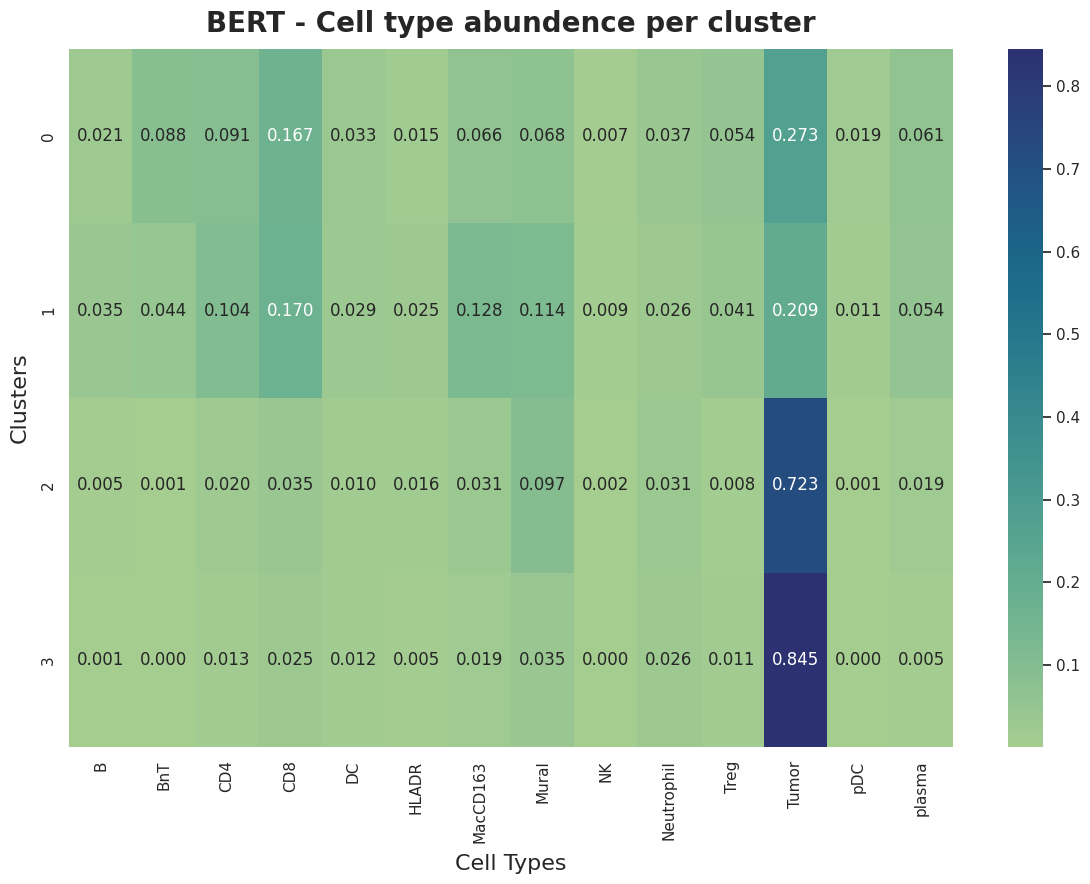

In [ ]:
# Cell type abundance and marker analysis based on Bert-Charter
cell_type_abundance = train_anndata.obs.groupby('cluster_bert', observed=True)['celltypes']\
                      .value_counts(normalize=True).unstack()
plot_heatmap(cell_type_abundance, "BERT - Cell type abundence per cluster", ".3f")

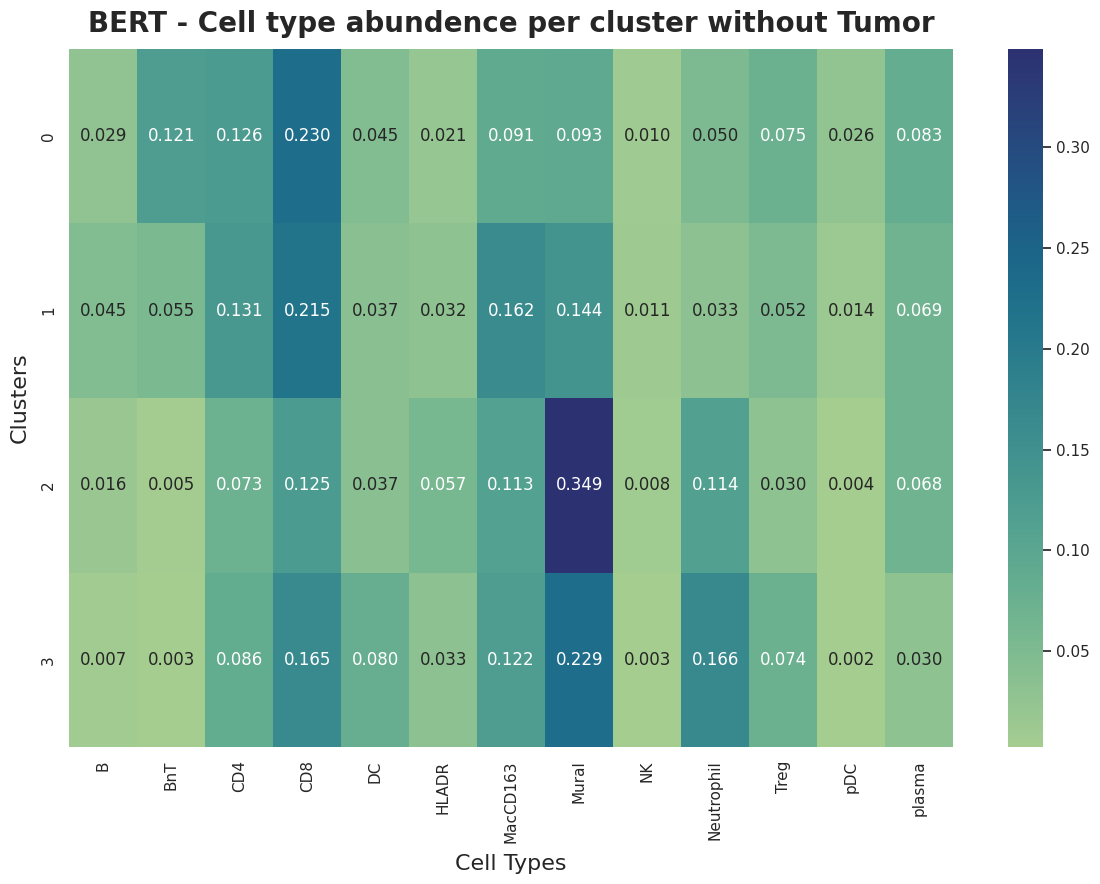

In [ ]:
cell_type_abundance = train_anndata.obs.groupby('cluster_bert', observed=True)['celltypes']\
                      .value_counts().unstack()
cell_type_abundance.drop(columns=['Tumor'], inplace=True)
cell_type_abundance = cell_type_abundance.div(cell_type_abundance.sum(axis=1), axis=0)
plot_heatmap(cell_type_abundance, "BERT - Cell type abundence per cluster without Tumor", ".3f")

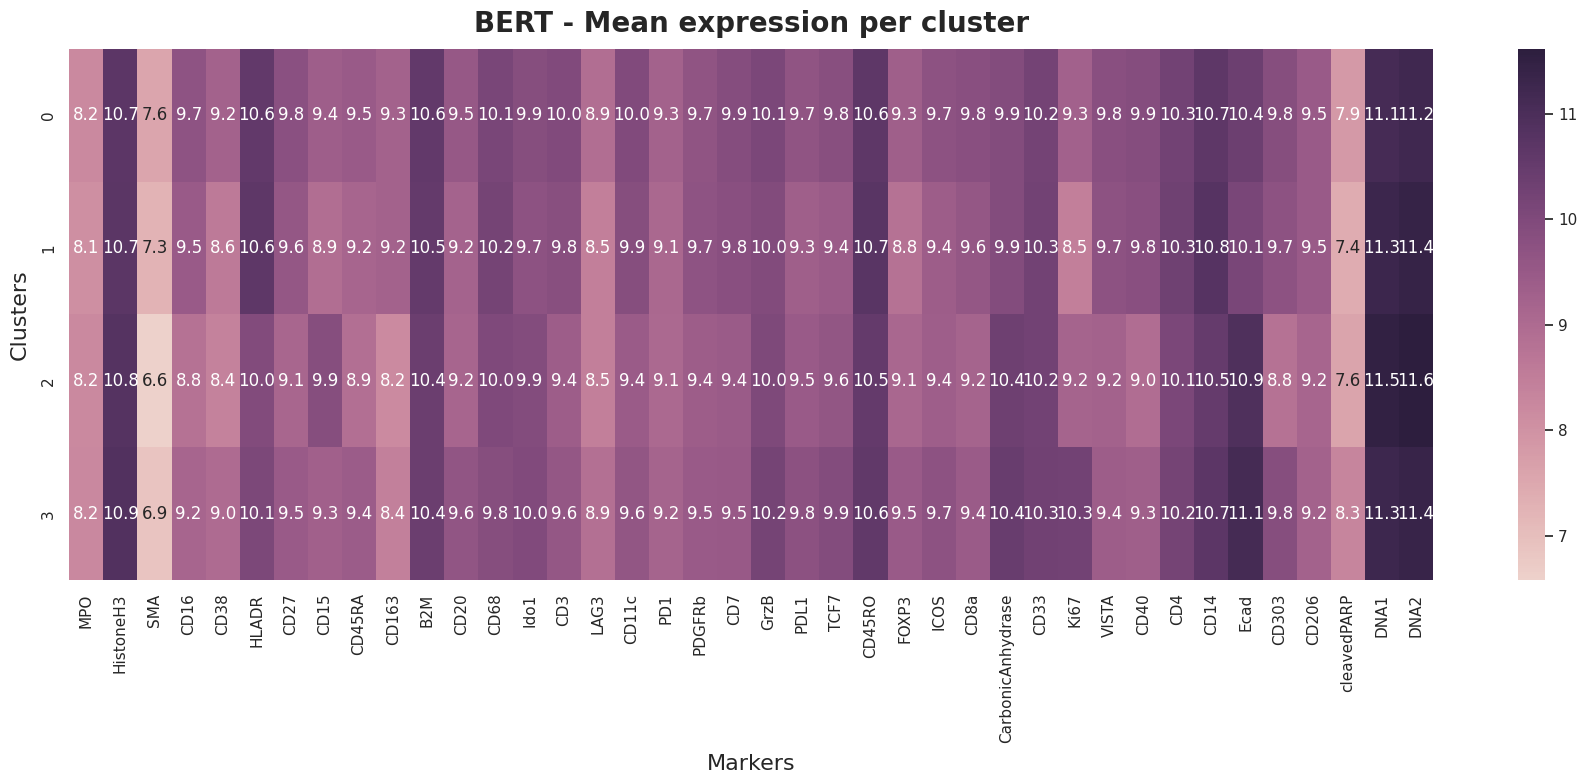

In [ ]:
best_cluster = 4
clusters_exprs = []

for cluster in range(best_cluster):
    mask = train_anndata.obs['cluster_bert'] == cluster
    cluster_data = train_anndata.layers['normalised_exprs'][mask, :]
    clusters_exprs.append(cluster_data.mean(axis=0))

expressions_clusters_df = pd.DataFrame(
    np.stack(clusters_exprs),
    columns=train_anndata.var['marker'],
    index=[f'{i}' for i in range(best_cluster)]
)

plot_heatmap(expressions_clusters_df, "BERT - Mean expression per cluster", ".1f", (18, 8), "Markers")

In [ ]:
# Comparison of the results
ct_left, ct_right = make_cross_matrix(train_anndata.obs, 'cluster_bert', 'cluster_cellcharter')
plot_cross_heatmap(ct_left, ct_right, f"Clusters BERT vs PCA")

ct_left, ct_right = make_cross_matrix(train_anndata.obs, 'cluster_bert', 'cluster_scvi')
plot_cross_heatmap(ct_left, ct_right, f"Clusters BERT vs SCvi")

ct_left, ct_right = make_cross_matrix(train_anndata.obs, 'cluster_cellcharter', 'cluster_scvi')
plot_cross_heatmap(ct_left, ct_right, f"Clusters PCA vs SCvi")

NameError: name 'make_cross_matrix' is not defined